In [12]:
import matplotlib.pyplot as plt
import pickle
import numpy as np
legend_properties = {'weight':'bold'}

In [13]:
data_folder = r"/Volumes/T7/data/dao-0310-23/Sensitivity/March_p1p2_2"
hierarchy_performance_file = data_folder + r"/hierarchy_performance"
hierarchy_performance_file_2 = data_folder + r"/hierarchy_performance_2"
with open(hierarchy_performance_file, 'rb') as infile:
    hierarchy_performance = pickle.load(infile)
with open(hierarchy_performance_file_2, 'rb') as infile:
    hierarchy_performance_2 = pickle.load(infile)
hierarchy_performance = np.hstack((hierarchy_performance, hierarchy_performance_2))
print(np.array(hierarchy_performance).shape)

(19, 19)


In [14]:
# Define more colors
# NUS two colors
nus_blue = "#003D7C"
nus_orange = "#EF7C00"
# Nature three colors
nature_orange = "#F16C23"
nature_blue = "#2B6A99"
nature_green = "#1B7C3D"
# Morandi six colors
morandi_blue = "#046586"
morandi_green =  "#28A9A1"
morandi_yellow = "#C9A77C"
morandi_orange = "#F4A016"
morandi_pink = "#F6BBC6"
morandi_red = "#E71F19"
morandi_purple = "#B08BEB"
# Others
shallow_grey = "#D3D4D3"
deep_grey = "#A6ABB6"

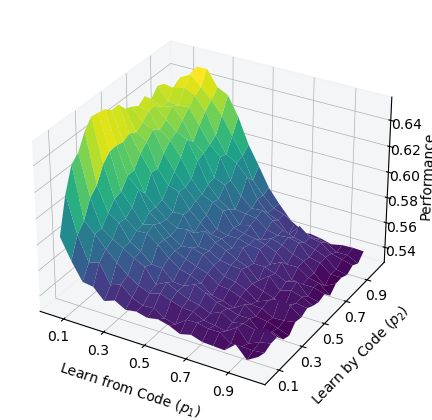

In [15]:
# 3D surface for March's (1991) seminal work
data = hierarchy_performance

# Create a meshgrid for X and Y
X = np.linspace(0.05, 1.0, 19)  # p2
Y = np.linspace(0.05, 1.0, 19)  # p1
X, Y = np.meshgrid(X, Y)
# Create the figure and axis
fig = plt.figure(figsize=(10, 12))  # Adjust the figure size as needed
# Move the subplot slightly to the left
fig.subplots_adjust(left=0.5)
ax = fig.add_subplot(111, projection='3d')

# Plot the 3D surface with grey colors
# cmap = cm.get_cmap('Greys')  # Custom colormap with grey shades
ax.plot_surface(Y, X, data, cmap='viridis')

# Set labels and title
ax.set_xlabel('Learn from Code ($p_1$)', labelpad=1) # learning from code
ax.set_ylabel('Learn by Code ($p_2$)', labelpad=1)  # learning by code
ax.set_zlabel('Performance', labelpad=-3.5)  # Increase labelpad for z-axis
# ax.set_title("Performance across $p_1$, $p_2$")
ax.set_xticks(np.arange(0.1, 1.0, 0.2))
ax.set_yticks(np.arange(0.1, 1.0, 0.2))
ax.xaxis.set_tick_params(pad=-2)
ax.yaxis.set_tick_params(pad=-2)
ax.zaxis.set_tick_params(pad=-1)
# ax.set_zlim([0.64, 0.80])
# Show the plot
plt.savefig(data_folder + r"/p1p2_curve.png", transparent=True, dpi=500)
plt.show()

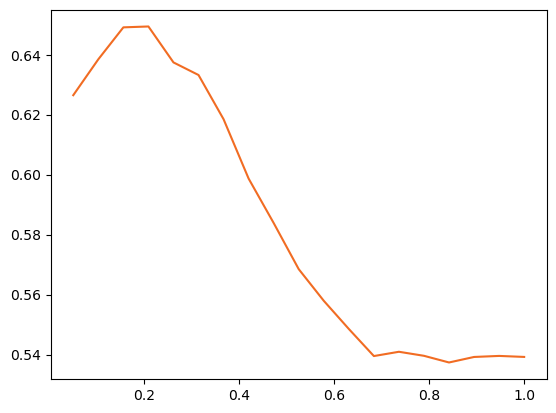

In [16]:
fig = plt.figure()
ax = fig.add_subplot()
x = np.linspace(0.05, 1.0, 19)
seperating_line = [performance_list[-1] for performance_list in hierarchy_performance]
line_1 = ax.plot(x, seperating_line, "-", color=nature_orange, label="Performance")
plt.show()

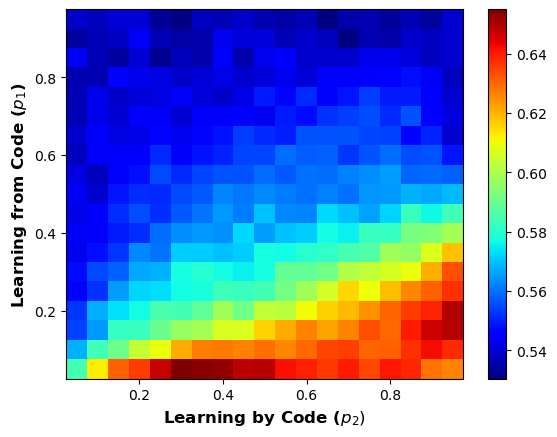

In [17]:
# heatmap figure to replace the 3D surface
import numpy as np
import matplotlib.pyplot as plt
K_list = [0, 1, 2, 3, 4, 5, 6, 7, 8]
# Generate some sample data
x = np.arange(0.05, 1.0, 0.05)
y = np.arange(0.05, 1.0, 0.05)
# p1 belief learning from code
# p2 code learning from belief
X, Y = np.meshgrid(x, y)     # Create a grid of x and y values
gs_fitness_across_p1p2 = np.array(hierarchy_performance)
z = gs_fitness_across_p1p2
# Create the 2D color plot
plt.pcolormesh(x, y, z, cmap='jet')
plt.colorbar()  # Add a colorbar for reference

# Set the axis labels and title
plt.xlabel('Learning by Code ($p_2)$', fontweight='bold', fontsize=12)
# plt.xticks(x)
# plt.yticks(y)
plt.ylabel('Learning from Code ($p_1$)',  fontweight='bold', fontsize=12)
# plt.title("(b) March's (1991) Model")
fig.tight_layout()
plt.savefig(data_folder + r"/March_model_p1p2.png", transparent=True, dpi=300)
# Display the plot
plt.show()

In [18]:
print(np.arange(0.1, 0.9, 0.1))

[0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8]


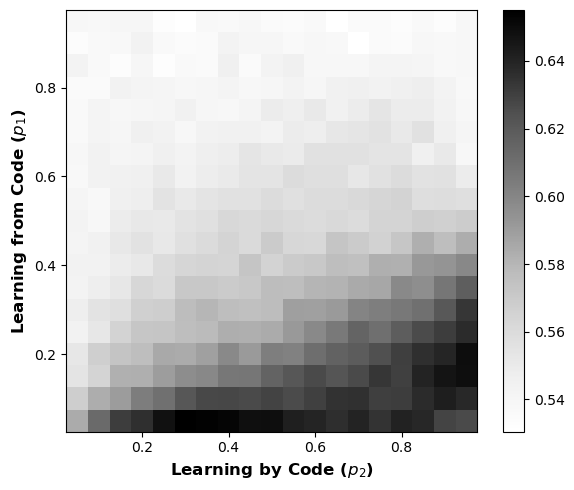

In [19]:
# heatmap figure in black-gray-white
import numpy as np
import matplotlib.pyplot as plt

K_list = [0, 1, 2, 3, 4, 5, 6, 7, 8]

x = np.arange(0.05, 1.0, 0.05)
y = np.arange(0.05, 1.0, 0.05)

X, Y = np.meshgrid(x, y)

gs_fitness_across_p1p2 = np.array(hierarchy_performance)
z = gs_fitness_across_p1p2

fig, ax = plt.subplots(figsize=(6, 5))

# grayscale heatmap
heatmap = ax.pcolormesh(
    x,
    y,
    z,
    cmap="Greys",      # black-gray-white
    shading="auto"
)

cbar = fig.colorbar(heatmap, ax=ax)
cbar.ax.tick_params(labelsize=10)

ax.set_xlabel(
    'Learning by Code ($p_2$)',
    fontweight='bold',
    fontsize=12
)

ax.set_ylabel(
    'Learning from Code ($p_1$)',
    fontweight='bold',
    fontsize=12
)

plt.tight_layout()
plt.savefig(
    data_folder + r"/March_model_p1p2_bw.png",
    transparent=True,
    dpi=300
)

plt.show()